In [20]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))


from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
from src.data_models.caravanify import Caravanify, CaravanifyConfig


# Step 1: Extract Anthropogenic Attributes

A good source for anthropogenic attributes is the following link: https://data.hydrosheds.org/file/technical-documentation/BasinATLAS_Catalog_v10.pdf   


In [32]:
config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/shapefiles",
    gauge_id_prefix="CA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)
# Load the static attributes for all gauges

caravan = Caravanify(config)
ids_for_training = caravan.get_all_gauge_ids()[:100]
caravan.load_stations(ids_for_training)
static_data = caravan.get_static_attributes()

# Identify anthropogenic attributes in the dataset
anthro_columns = [
    "ppd_pk_sav",  # Population density
    "urb_pc_sse",  # Urban extent
    "rdd_mk_sav",  # Road density
    "nli_ix_sav",  # Nighttime lights
    "gdp_ud_sav",  # GDP
    "hdi_ix_sav",  # Human development index
    "dor_pc_pva",  #  Degree or regulation
    "rev_mc_usu",  # Reservoir volume
]

# Check which attributes are actually present in the dataset
available_anthro = [col for col in anthro_columns if col in static_data.columns]
print(f"Available anthropogenic attributes: {available_anthro}")

# Create subset with only anthropogenic attributes and gauge_id
anthro_data = static_data[["gauge_id"] + available_anthro].copy()
print("\nAnthropogenic attributes data:")
print(anthro_data.head())

Available anthropogenic attributes: ['ppd_pk_sav', 'urb_pc_sse', 'rdd_mk_sav', 'nli_ix_sav', 'gdp_ud_sav', 'hdi_ix_sav', 'dor_pc_pva', 'rev_mc_usu']

Anthropogenic attributes data:
   gauge_id  ppd_pk_sav  urb_pc_sse  rdd_mk_sav  nli_ix_sav   gdp_ud_sav  \
0  CA_15013   10.883812    0.000000  221.599123   72.633114  4229.709074   
1  CA_15016    7.385230    0.000000  160.634394   12.784100  4218.000000   
2  CA_15020    7.374999    0.040389   22.641699   21.087189  4218.000000   
3  CA_15022    7.375000    0.000000   11.091105    9.472136  4218.000000   
4  CA_15025    7.371179    2.514909   56.449445  223.970322  4218.000000   

   hdi_ix_sav  dor_pc_pva  rev_mc_usu  
0   664.06355           0           0  
1   664.00000           0           0  
2   664.00000           0           0  
3   664.00000           0           0  
4   664.00000           0           0  


# Step 2: Handle Missing Values

In [33]:
# Check for missing values
missing_values = anthro_data.isna().sum()
print("Missing values per attribute:")
print(missing_values)

# Impute missing values with median
for col in available_anthro:
   if anthro_data[col].isna().any():
       median_val = anthro_data[col].median()
       anthro_data[col].fillna(median_val, inplace=True)

print("\nAfter imputation - missing values:")
print(anthro_data.isna().sum())

Missing values per attribute:
gauge_id      0
ppd_pk_sav    0
urb_pc_sse    0
rdd_mk_sav    0
nli_ix_sav    0
gdp_ud_sav    0
hdi_ix_sav    0
dor_pc_pva    0
rev_mc_usu    0
dtype: int64

After imputation - missing values:
gauge_id      0
ppd_pk_sav    0
urb_pc_sse    0
rdd_mk_sav    0
nli_ix_sav    0
gdp_ud_sav    0
hdi_ix_sav    0
dor_pc_pva    0
rev_mc_usu    0
dtype: int64


# Step 3: Normalize Attributes


In [34]:

# Initialize the scaler
scaler = MinMaxScaler()

# Fit and transform the data (excluding gauge_id)
norm_data = pd.DataFrame(
   scaler.fit_transform(anthro_data[available_anthro]),
   columns=available_anthro
)

# Add gauge_id back to normalized data
norm_data['gauge_id'] = anthro_data['gauge_id'].values

print("Normalized anthropogenic attributes:")
print(norm_data.head())

Normalized anthropogenic attributes:
   ppd_pk_sav  urb_pc_sse  rdd_mk_sav  nli_ix_sav  gdp_ud_sav  hdi_ix_sav  \
0    0.032776    0.000000    0.709692    0.163690    0.483351    0.710715   
1    0.012455    0.000000    0.514214    0.028811    0.481190    0.709497   
2    0.012396    0.007944    0.071752    0.047523    0.481190    0.709497   
3    0.012396    0.000000    0.034716    0.021347    0.481190    0.709497   
4    0.012374    0.494640    0.180153    0.504753    0.481190    0.709497   

   dor_pc_pva  rev_mc_usu  gauge_id  
0         0.0         0.0  CA_15013  
1         0.0         0.0  CA_15016  
2         0.0         0.0  CA_15020  
3         0.0         0.0  CA_15022  
4         0.0         0.0  CA_15025  


# Step 4: Define weights and calculate Human Influence Index (HII)


In [35]:
# weights = {attr: 1/len(available_anthro) for attr in available_anthro}
# print("Weights assigned to each attribute:")
# print(weights)

# anthro_columns = [
#     "ppd_pk_sav",  # Population density
#     "urb_pc_sse",  # Urban extent
#     "rdd_mk_sav",  # Road density
#     "nli_ix_sav",  # Nighttime lights
#     "hf_ix_s93",  # Human footprint 1993
#     "hf_ix_s09",  # Human footprint 2009
#     "gdp_ud_sav",  # GDP
#     "hdi_ix_sav",  # Human development index
#     "dor_pc_pva",  #  Degree or regulation
#     "rev_mc_usu",  # Reservoir volume
# ]

weights_raw = {'ppd_pk_sav':1, 'urb_pc_sse':1, 'rdd_mk_sav':1, 'nli_ix_sav':1, 'gdp_ud_sav':3, 'hdi_ix_sav':1, 'dor_pc_pva':5, 'rev_mc_usu':5}

weights = {attr: 1/len(available_anthro) for attr in available_anthro}
for attr in available_anthro:
    if attr in weights_raw:
        weights[attr] = weights_raw[attr] / sum(weights_raw.values())
    else:
        weights[attr] = 0


assert sum(weights.values()) == 1, "Weights should sum up to 1"

print("Weights assigned to each attribute:")
print(weights)



Weights assigned to each attribute:
{'ppd_pk_sav': 0.05555555555555555, 'urb_pc_sse': 0.05555555555555555, 'rdd_mk_sav': 0.05555555555555555, 'nli_ix_sav': 0.05555555555555555, 'gdp_ud_sav': 0.16666666666666666, 'hdi_ix_sav': 0.05555555555555555, 'dor_pc_pva': 0.2777777777777778, 'rev_mc_usu': 0.2777777777777778}


In [36]:
available_anthro

['ppd_pk_sav',
 'urb_pc_sse',
 'rdd_mk_sav',
 'nli_ix_sav',
 'gdp_ud_sav',
 'hdi_ix_sav',
 'dor_pc_pva',
 'rev_mc_usu']

In [37]:
# Calculate HII (weighted sum of normalized attributes)
hii_values = np.zeros(len(norm_data))

for attr in available_anthro:
   hii_values += weights[attr] * norm_data[attr].values

# Add HII to the normalized data
norm_data['hii'] = hii_values / np.max(hii_values)

print("\nData with HII scores:")
print(norm_data[['gauge_id', 'hii']].head())


Data with HII scores:
   gauge_id       hii
0  CA_15013  0.253116
1  CA_15016  0.223538
2  CA_15020  0.189217
3  CA_15022  0.183344
4  CA_15025  0.276064


# Step 5: Categorize catchments based on HII



Count of catchments in each category:
human_influence_category
Low       72
Medium     5
High       1
Name: count, dtype: int64

Final classification with original values:
   gauge_id       hii human_influence_category  ppd_pk_sav  urb_pc_sse  \
0  CA_15013  0.253116                      Low   10.883812    0.000000   
1  CA_15016  0.223538                      Low    7.385230    0.000000   
2  CA_15020  0.189217                      Low    7.374999    0.040389   
3  CA_15022  0.183344                      Low    7.375000    0.000000   
4  CA_15025  0.276064                      Low    7.371179    2.514909   

   rdd_mk_sav  nli_ix_sav   gdp_ud_sav  hdi_ix_sav  dor_pc_pva  rev_mc_usu  
0  221.599123   72.633114  4229.709074   664.06355           0           0  
1  160.634394   12.784100  4218.000000   664.00000           0           0  
2   22.641699   21.087189  4218.000000   664.00000           0           0  
3   11.091105    9.472136  4218.000000   664.00000           0           0

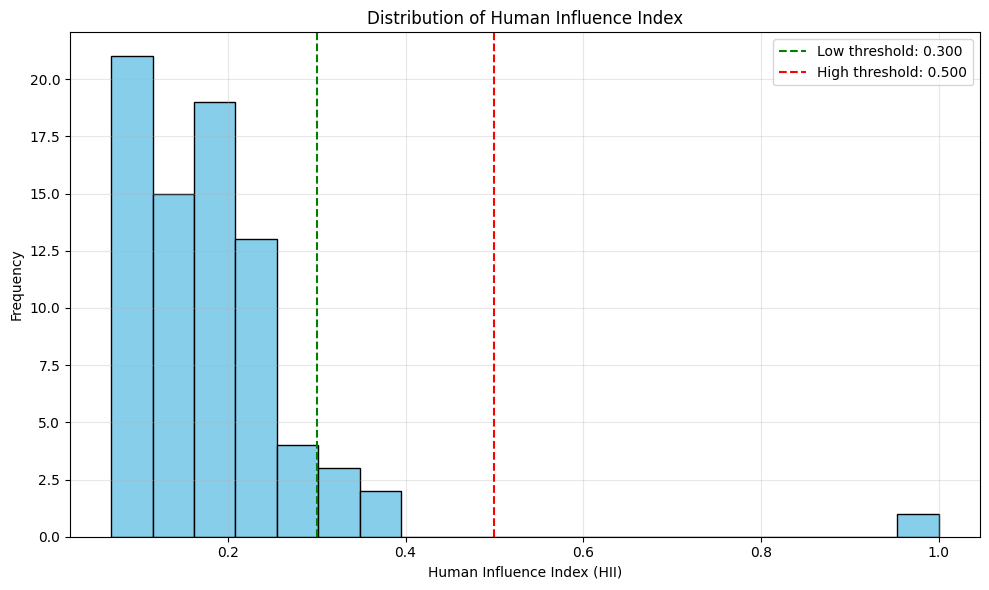

In [41]:
# Define thresholds for categories (using tertiles)
low_threshold = 0.3
high_threshold = 0.5

# Assign categories
def assign_category(hii):
   if hii < low_threshold:
       return "Low"
   elif hii < high_threshold:
       return "Medium"
   else:
       return "High"

norm_data['human_influence_category'] = norm_data['hii'].apply(assign_category)

# Count catchments in each category
category_counts = norm_data['human_influence_category'].value_counts()
print("\nCount of catchments in each category:")
print(category_counts)

# Add original attributes to the output
result_df = pd.merge(
   norm_data[['gauge_id', 'hii', 'human_influence_category']],
   anthro_data,
   on='gauge_id'
)

print("\nFinal classification with original values:")
print(result_df.head())

basin_count = len(ids_for_training)
number_of_bins = int(np.ceil(2 * basin_count ** (1/3)))


plt.figure(figsize=(10, 6))
plt.hist(norm_data['hii'], bins=20, color='skyblue', edgecolor='black')
plt.axvline(low_threshold, color='green', linestyle='--', label=f'Low threshold: {low_threshold:.3f}')
plt.axvline(high_threshold, color='red', linestyle='--', label=f'High threshold: {high_threshold:.3f}')
plt.xlabel('Human Influence Index (HII)')
plt.ylabel('Frequency')
plt.title('Distribution of Human Influence Index')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 6: Plot streamflow data for examples from each category


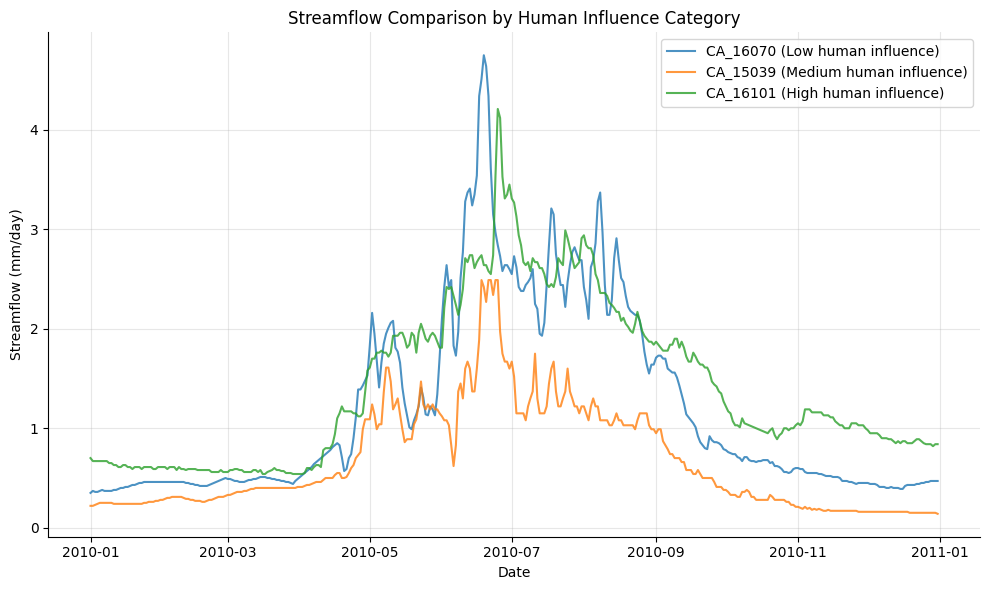


Comparison of human influence metrics:


,gauge_id,human_influence_category,hii,ppd_pk_sav,urb_pc_sse,rdd_mk_sav,nli_ix_sav,gdp_ud_sav,hdi_ix_sav,dor_pc_pva,rev_mc_usu
7,CA_15039,Medium,0.334410,6.299732,2.990781,219.011128,267.606882,4218.000000,664.0,0,0
38,CA_16070,Low,0.170112,6.649812,0.000000,38.173449,0.023679,3817.692446,664.0,0,0
41,CA_16101,High,1.000000,34.670282,0.597663,60.254535,87.053617,2929.660577,664.0,1824,19500


In [42]:
# Get one example from each category
example_gauges = {}
for category in ["Low", "Medium", "High"]:
    # Randomly select a gauge_id for each category
    category_gauges = result_df[result_df["human_influence_category"] == category][
        "gauge_id"
    ].values
    if len(category_gauges) > 0:
        example_gauges[category] = np.random.choice(category_gauges)
    else:
        print(f"No catchments in {category} category")

# Plot streamflow time series for each example
plt.figure(figsize=(10, 6))

all_ts_data = caravan.get_time_series()

for category, gauge_id in example_gauges.items():
    ts_data = all_ts_data[all_ts_data["gauge_id"] == gauge_id]

    # Keep only data from 2000 to 2001
    ts_data = ts_data[
        (ts_data["date"] >= "2010-01-01") & (ts_data["date"] <= "2010-12-31")
    ]

    if len(ts_data) > 0 and "streamflow" in ts_data.columns:
        # Convert date to datetime if needed
        if not pd.api.types.is_datetime64_any_dtype(ts_data["date"]):
            ts_data["date"] = pd.to_datetime(ts_data["date"])

        # Plot streamflow
        plt.plot(
            ts_data["date"],
            ts_data["streamflow"],
            label=f"{gauge_id} ({category} human influence)",
            alpha=0.8,
        )
    else:
        print(f"No streamflow data available for {gauge_id}")

plt.xlabel("Date")
plt.ylabel("Streamflow (mm/day)")
plt.title("Streamflow Comparison by Human Influence Category")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
sns.despine()
plt.show()

# Create a table with human influence metrics for the examples
comparison_df = result_df[result_df["gauge_id"].isin(example_gauges.values())]
print("\nComparison of human influence metrics:")
display(
    comparison_df[["gauge_id", "human_influence_category", "hii"] + available_anthro]
)

Basin CH_2239 not found in the dataset.
No streamflow data available for CH_2239


/var/folders/y6/kqwqph4s3sj7hkxryrly5y6r0000gn/T/ipykernel_70537/341041637.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


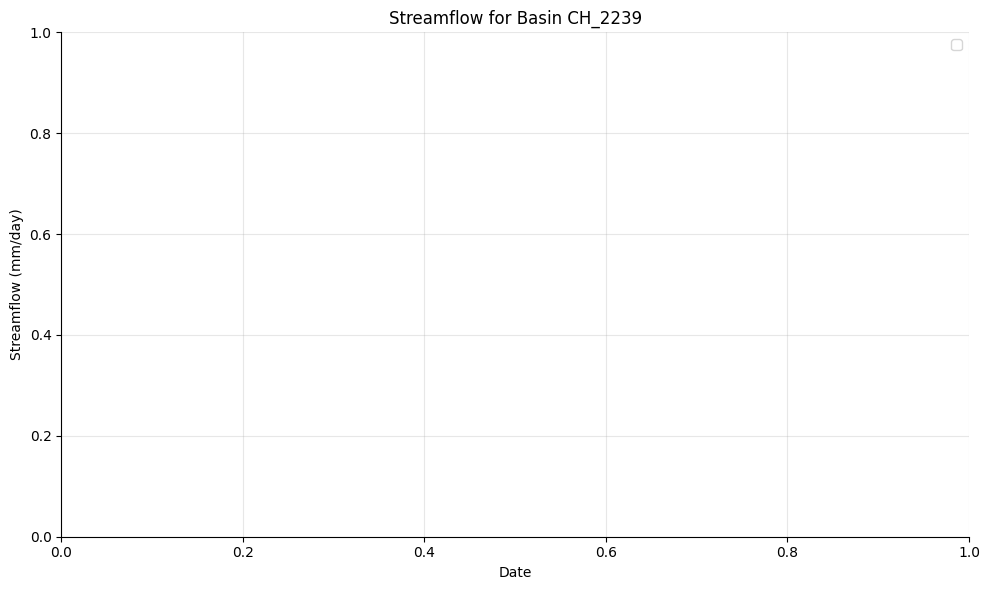

In [43]:
# Find basin CH_2239
basin_id = "CH_2239"
if basin_id in result_df["gauge_id"].values:
    basin_data = result_df[result_df["gauge_id"] == basin_id]
    print(f"\nData for basin {basin_id}:")
    display(basin_data)
else:
    print(f"Basin {basin_id} not found in the dataset.")

# Plot streamflow time series for basin CH_2239
plt.figure(figsize=(10, 6))
ts_data = all_ts_data[all_ts_data["gauge_id"] == basin_id]
ts_data = ts_data[
    (ts_data["date"] >= "2000-01-01") & (ts_data["date"] <= "2003-12-31")
]
if len(ts_data) > 0 and "streamflow" in ts_data.columns:
    if not pd.api.types.is_datetime64_any_dtype(ts_data["date"]):
        ts_data["date"] = pd.to_datetime(ts_data["date"])

    plt.plot(
        ts_data["date"],
        ts_data["streamflow"],
        label=f"{basin_id}",
        alpha=0.8,
    )
else:
    print(f"No streamflow data available for {basin_id}")
plt.xlabel("Date")
plt.ylabel("Streamflow (mm/day)")
plt.title(f"Streamflow for Basin {basin_id}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
sns.despine()
plt.show()